PHASE 1:
- Download 1 dataset từ NAB — gợi ý: realKnownCause/ vì có ground truth label
- Trong assignment.ipynb:
- Load data, plot raw time series
- Tính basic stats: mean, std, skewness (dùng scipy.stats.skew), min, max
- Plot histogram + density → data có Gaussian không? Skewed không? (dùng kiến thức section 1)
- Plot ACF (statsmodels.graphics.tsaplots.plot_acf) → có seasonal không? Period bao nhiêu?
- Kết luận: data thuộc loại nào (stationary? seasonal? skewed?) → phương pháp nào phù hợp nhất, tại sao

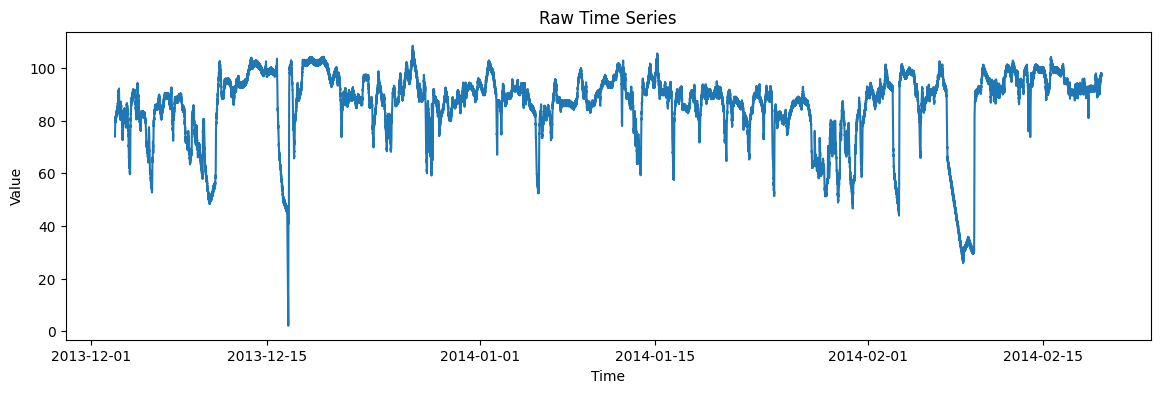

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('D:\Xbrain\Phase 2 AIops\machine_temperature_system_failure.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

# Plot raw time series
plt.figure(figsize=(14, 4))
plt.plot(df['value'])
plt.title('Raw Time Series')
plt.xlabel('Time')
plt.ylabel('Value')
plt.show()

In [2]:
from scipy import stats

print('Mean:    ', df['value'].mean().round(2))
print('Std:     ', df['value'].std().round(2))
print('Min:     ', df['value'].min().round(2))
print('Max:     ', df['value'].max().round(2))
print('Skewness:', stats.skew(df['value']).round(2))

Mean:     85.93
Std:      13.75
Min:      2.08
Max:      108.51
Skewness: -1.83


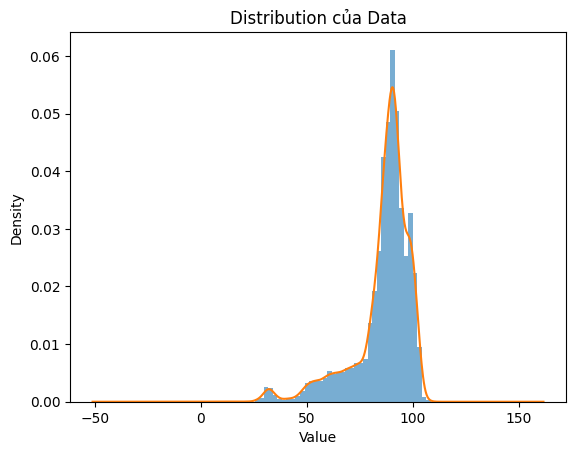

In [3]:
df['value'].plot(kind='hist', bins=50, density=True, alpha=0.6)
df['value'].plot(kind='kde')  # đường cong density
plt.title('Distribution của Data')
plt.xlabel('Value')
plt.show()

In [5]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 699.0 kB/s eta 0:00:13
   -- ------------------------------------- 0.5/9.6 MB 699.0 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/9.6 MB 670.4 kB/s eta 0:00:14
   ---- ----------------------------------- 1.0/9.6 MB 718.9 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.6 MB 798.6 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/9.6 MB 855.6 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.6 MB 906.5 kB/s eta 0:00:09
   -------- ------------------------------- 2.1/9.6 MB 939.1 kB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.6 MB 972.3 kB/s eta 0:00:08
   --------- ---------

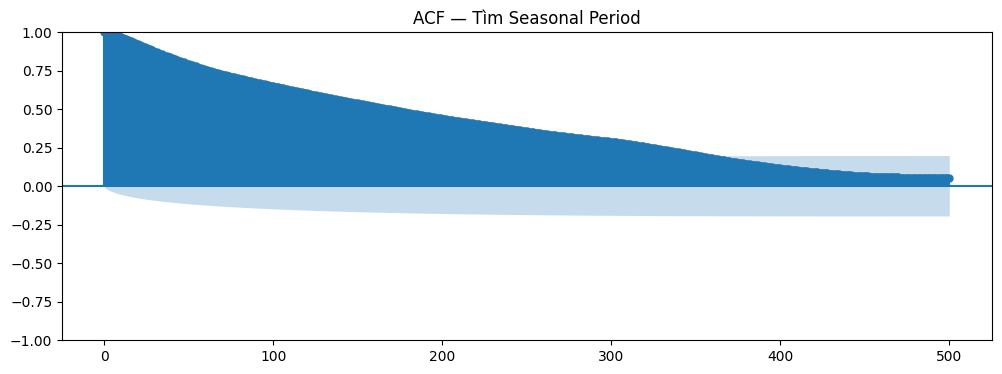

In [4]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['value'], lags=500, ax=ax)
plt.title('ACF — Tìm Seasonal Period')
plt.show()

=> Cho thấy hình dạng không phải bell curve đối xứng, đỉnh lệch hẳn về phía phải (85-100), đuôi kéo dài về trái. Không phải Gaussian.
=> skewed nặng với skewness = -1.83
=> Không Seasonal 
=> Phương pháp phù hợp nhất là IQR làm detector 1 vì không giả định distribution, dùng percentile nên robust với skewed data, detect được các cú drop bất thường ở đuôi trái

Ground truth anomalies: 4 / 22695
IQR bounds: lower=66.68, upper=110.42
Predicted anomalies: 2298 / 22695

Precision : 0.001
Recall    : 0.750
F1        : 0.003

Tuning k:
k      Precision    Recall     F1       #Detected
1.0    0.001        0.750      0.002    3021
1.5    0.001        0.750      0.003    2298
2.0    0.002        0.750      0.004    1677
2.5    0.003        0.750      0.005    1146
3.0    0.003        0.500      0.006    711


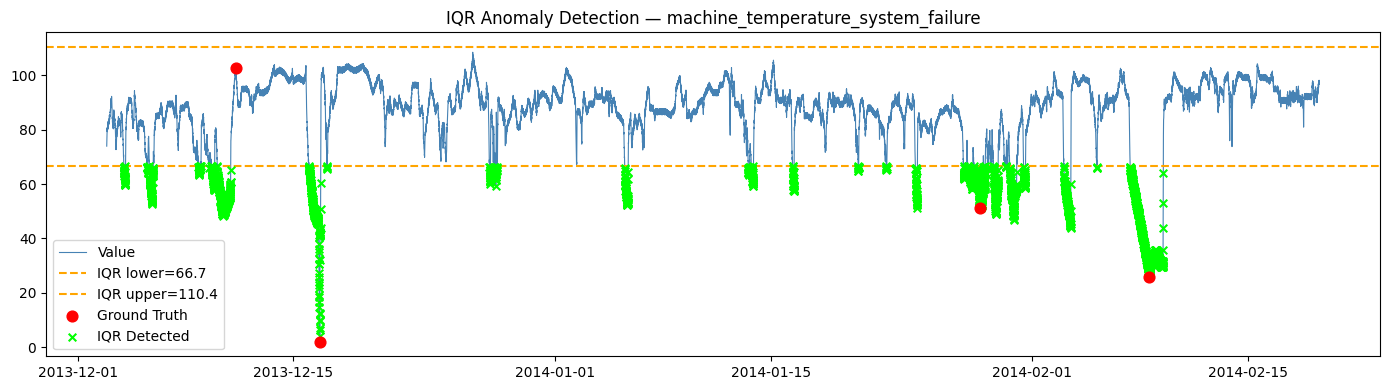

In [8]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# ── 1. LOAD DATA ──────────────────────────────────────────────
df = pd.read_csv(r"D:\Xbrain\Phase 2 AIops\machine_temperature_system_failure.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# ── 2. LOAD GROUND TRUTH LABELS ───────────────────────────────
with open(r"D:\Xbrain\Phase 2 AIops\combined_labels.json", "r") as f:
    all_labels = json.load(f)

label_key = "realKnownCause/machine_temperature_system_failure.csv"
anomaly_timestamps = pd.to_datetime(all_labels[label_key])

df['ground_truth'] = df['timestamp'].isin(anomaly_timestamps).astype(int)
print(f"Ground truth anomalies: {df['ground_truth'].sum()} / {len(df)}")

# ── 3. IQR DETECTOR ───────────────────────────────────────────
def detect_iqr(series, k=1.5):
    Q1 = np.percentile(series, 25)
    Q3 = np.percentile(series, 75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (series < lower) | (series > upper), lower, upper

anomalies_bool, lower, upper = detect_iqr(df['value'].values)
df['predicted'] = anomalies_bool.astype(int)

print(f"IQR bounds: lower={lower:.2f}, upper={upper:.2f}")
print(f"Predicted anomalies: {df['predicted'].sum()} / {len(df)}")

# ── 4. PRECISION / RECALL / F1 ────────────────────────────────
precision = precision_score(df['ground_truth'], df['predicted'], zero_division=0)
recall    = recall_score(df['ground_truth'],    df['predicted'], zero_division=0)
f1        = f1_score(df['ground_truth'],        df['predicted'], zero_division=0)

print(f"\n{'='*35}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1        : {f1:.3f}")
print(f"{'='*35}")

# ── 5. TUNE k ─────────────────────────────────────────────────
print("\nTuning k:")
print(f"{'k':<6} {'Precision':<12} {'Recall':<10} {'F1':<8} {'#Detected'}")
for k in [1.0, 1.5, 2.0, 2.5, 3.0]:
    pred, lo, hi = detect_iqr(df['value'].values, k=k)
    p = precision_score(df['ground_truth'], pred.astype(int), zero_division=0)
    r = recall_score(df['ground_truth'],    pred.astype(int), zero_division=0)
    f = f1_score(df['ground_truth'],        pred.astype(int), zero_division=0)
    print(f"{k:<6} {p:<12.3f} {r:<10.3f} {f:<8.3f} {pred.sum()}")

# ── 6. PLOT ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['timestamp'], df['value'], color='steelblue', linewidth=0.8, label='Value')
ax.axhline(lower, color='orange', linestyle='--', label=f'IQR lower={lower:.1f}')
ax.axhline(upper, color='orange', linestyle='--', label=f'IQR upper={upper:.1f}')

gt      = df[df['ground_truth'] == 1]
pred_df = df[df['predicted'] == 1]
ax.scatter(gt['timestamp'],      gt['value'],      color='red',  s=60, zorder=5, label='Ground Truth')
ax.scatter(pred_df['timestamp'], pred_df['value'], color='lime', s=30, marker='x', zorder=4, label='IQR Detected')

ax.set_title('IQR Anomaly Detection — machine_temperature_system_failure')
ax.legend()
plt.tight_layout()
plt.show()

Ground truth anomalies: 4 / 22695

[IQR k=2.5] lower=55.74 | upper=121.36
Precision: 0.003 | Recall: 0.750 | F1: 0.005 | #Detected: 1146

── Tune contamination (Isolation Forest) ──
Lần    contamination    Precision    Recall     F1       #Detected
────────────────────────────────────────────────────────────
1      0.01             0.004        0.250      0.009    225
2      0.02             0.004        0.500      0.009    450
3      0.05             0.002        0.500      0.004    1123

→ Best contamination: 0.02 (F1=0.009)

METRIC               Detector 1 (IQR)     Detector 2 (IF)
───────────────────────────────────────────────────────
Precision            0.003                0.004
Recall               0.750                0.500
F1                   0.005                0.009
#Detected            1146                 450


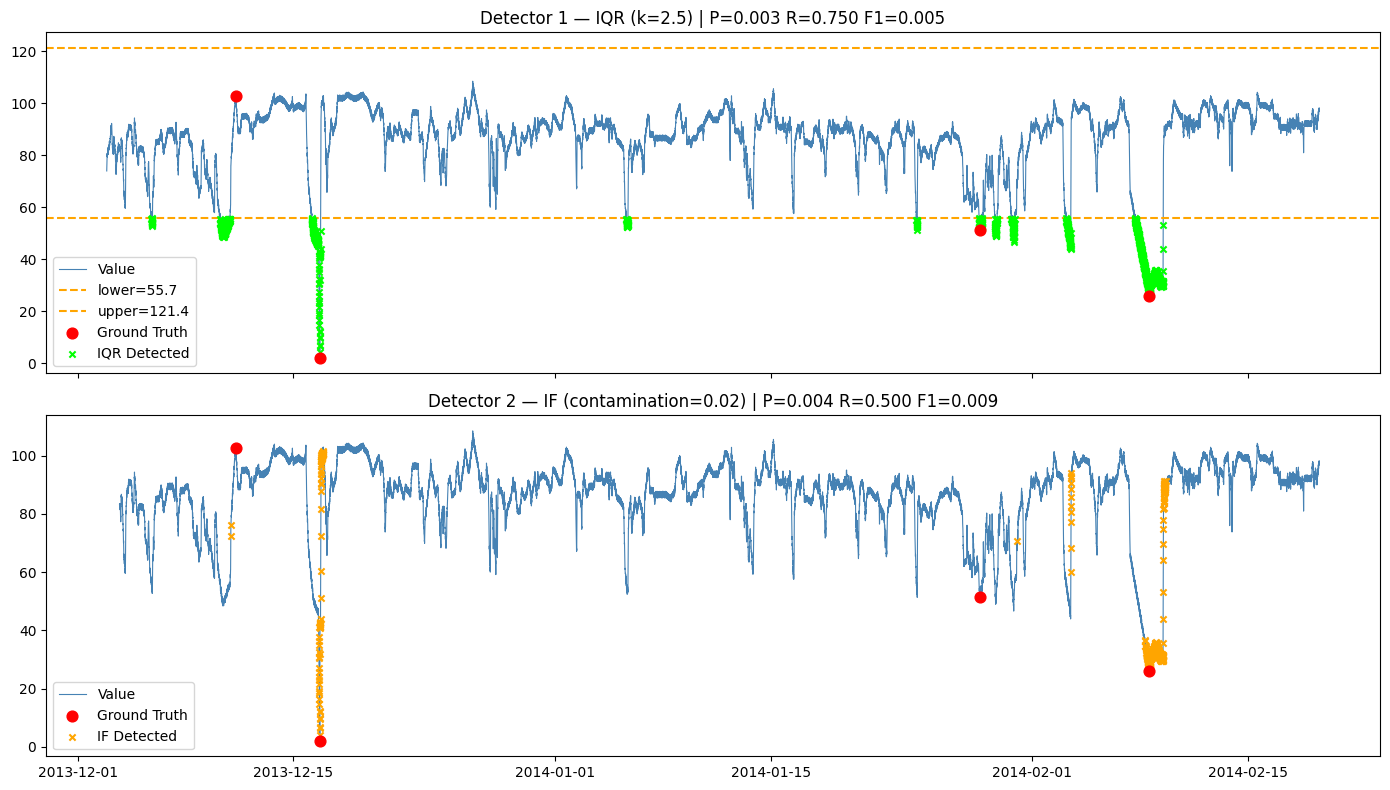

In [12]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest

# ── 1. LOAD DATA ──────────────────────────────────────────────
df = pd.read_csv(r"D:\Xbrain\Phase 2 AIops\machine_temperature_system_failure.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

# ── 2. LOAD GROUND TRUTH LABELS ───────────────────────────────
with open(r"D:\Xbrain\Phase 2 AIops\combined_labels.json", "r") as f:
    all_labels = json.load(f)

label_key = "realKnownCause/machine_temperature_system_failure.csv"
anomaly_timestamps = pd.to_datetime(all_labels[label_key])
df['ground_truth'] = df['timestamp'].isin(anomaly_timestamps).astype(int)
print(f"Ground truth anomalies: {df['ground_truth'].sum()} / {len(df)}")

# ── 3. IQR DETECTOR (k=2.5) ───────────────────────────────────
def detect_iqr(series, k=2.5):
    Q1 = np.percentile(series, 25)
    Q3 = np.percentile(series, 75)
    IQR = Q3 - Q1
    lower = Q1 - k * IQR
    upper = Q3 + k * IQR
    return (series < lower) | (series > upper), lower, upper

anomalies_bool, lower, upper = detect_iqr(df['value'].values, k=2.5)
df['pred_iqr'] = anomalies_bool.astype(int)

p_iqr = precision_score(df['ground_truth'], df['pred_iqr'], zero_division=0)
r_iqr = recall_score(df['ground_truth'],    df['pred_iqr'], zero_division=0)
f_iqr = f1_score(df['ground_truth'],        df['pred_iqr'], zero_division=0)
print(f"\n[IQR k=2.5] lower={lower:.2f} | upper={upper:.2f}")
print(f"Precision: {p_iqr:.3f} | Recall: {r_iqr:.3f} | F1: {f_iqr:.3f} | #Detected: {df['pred_iqr'].sum()}")

# ── 4. FEATURE ENGINEERING ────────────────────────────────────
def build_features(series, window=60):
    s = pd.Series(series)
    features = pd.DataFrame({
        'value'            : s,
        'rolling_mean_1h'  : s.rolling(window).mean(),
        'rolling_std_1h'   : s.rolling(window).std(),
        'rolling_mean_4h'  : s.rolling(window * 4).mean(),
        'rate_of_change'   : s.diff(),
        'rate_of_change_5' : s.diff(5),
        'lag_1'            : s.shift(1),
        'lag_60'           : s.shift(window),
        'z_score'          : (s - s.rolling(window).mean()) /
                             s.rolling(window).std().replace(0, 1e-10),
    })
    return features.dropna()

features_df = build_features(df['value'].values, window=60)
df_aligned  = df.iloc[features_df.index].copy()
X           = features_df.values

# ── 5. TUNE CONTAMINATION — 3 LẦN ────────────────────────────
print("\n── Tune contamination (Isolation Forest) ──")
print(f"{'Lần':<6} {'contamination':<16} {'Precision':<12} {'Recall':<10} {'F1':<8} {'#Detected'}")
print(f"{'─'*60}")

contamination_values = [0.01, 0.02, 0.05]  # 3 lần tune
best_f1   = -1
best_cont = 0.01
best_pred = None

for i, c in enumerate(contamination_values, 1):
    clf = IsolationForest(
        n_estimators=200,
        contamination=c,
        max_features=1.0,
        random_state=42
    )
    clf.fit(X)
    pred = (clf.predict(X) == -1).astype(int)
    p = precision_score(df_aligned['ground_truth'], pred, zero_division=0)
    r = recall_score(df_aligned['ground_truth'],    pred, zero_division=0)
    f = f1_score(df_aligned['ground_truth'],        pred, zero_division=0)
    print(f"{i:<6} {c:<16} {p:<12.3f} {r:<10.3f} {f:<8.3f} {pred.sum()}")

    if f > best_f1:
        best_f1   = f
        best_cont = c
        best_pred = pred.copy()

print(f"\n→ Best contamination: {best_cont} (F1={best_f1:.3f})")

# ── 6. FINAL IF VỚI BEST CONTAMINATION ───────────────────────
df_aligned['pred_if'] = best_pred
p_if = precision_score(df_aligned['ground_truth'], df_aligned['pred_if'], zero_division=0)
r_if = recall_score(df_aligned['ground_truth'],    df_aligned['pred_if'], zero_division=0)
f_if = f1_score(df_aligned['ground_truth'],        df_aligned['pred_if'], zero_division=0)

# ── 7. BẢNG SO SÁNH ──────────────────────────────────────────
print(f"\n{'='*55}")
print(f"{'METRIC':<20} {'Detector 1 (IQR)':<20} {'Detector 2 (IF)'}")
print(f"{'─'*55}")
print(f"{'Precision':<20} {p_iqr:<20.3f} {p_if:.3f}")
print(f"{'Recall':<20} {r_iqr:<20.3f} {r_if:.3f}")
print(f"{'F1':<20} {f_iqr:<20.3f} {f_if:.3f}")
print(f"{'#Detected':<20} {df['pred_iqr'].sum():<20} {df_aligned['pred_if'].sum()}")
print(f"{'='*55}")

# ── 8. PLOT ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1 — IQR
axes[0].plot(df['timestamp'], df['value'], color='steelblue', linewidth=0.8, label='Value')
axes[0].axhline(lower, color='orange', linestyle='--', label=f'lower={lower:.1f}')
axes[0].axhline(upper, color='orange', linestyle='--', label=f'upper={upper:.1f}')
gt    = df[df['ground_truth'] == 1]
p0_df = df[df['pred_iqr'] == 1]
axes[0].scatter(gt['timestamp'],    gt['value'],    color='red',  s=60, zorder=5, label='Ground Truth')
axes[0].scatter(p0_df['timestamp'], p0_df['value'], color='lime', s=20, marker='x', zorder=4, label='IQR Detected')
axes[0].set_title(f'Detector 1 — IQR (k=2.5) | P={p_iqr:.3f} R={r_iqr:.3f} F1={f_iqr:.3f}')
axes[0].legend()

# Panel 2 — IF
axes[1].plot(df_aligned['timestamp'], df_aligned['value'], color='steelblue', linewidth=0.8, label='Value')
gt2   = df_aligned[df_aligned['ground_truth'] == 1]
p1_df = df_aligned[df_aligned['pred_if'] == 1]
axes[1].scatter(gt2['timestamp'],   gt2['value'],   color='red',    s=60, zorder=5, label='Ground Truth')
axes[1].scatter(p1_df['timestamp'], p1_df['value'], color='orange', s=20, marker='x', zorder=4, label='IF Detected')
axes[1].set_title(f'Detector 2 — IF (contamination={best_cont}) | P={p_if:.3f} R={r_if:.3f} F1={f_if:.3f}')
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    precision  = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall     = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    far        = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Alarm Rate

    print(f"\n[{name}]")
    print(f"TP={tp} | FP={fp} | TN={tn} | FN={fn}")
    print(f"Precision  : {precision:.3f}")
    print(f"Recall     : {recall:.3f}")
    print(f"F1         : {f1:.3f}")
    print(f"False Alarm: {far:.4f} ({far*100:.2f}%) ← target < 1%")

# IQR
print_metrics(df['ground_truth'], df['pred_iqr'], "Detector 1 — IQR k=2.5")

# IF
print_metrics(df_aligned['ground_truth'], df_aligned['pred_if'], "Detector 2 — IF")


[Detector 1 — IQR k=2.5]
TP=3 | FP=1143 | TN=21548 | FN=1
Precision  : 0.003
Recall     : 0.750
F1         : 0.005
False Alarm: 0.0504 (5.04%) ← target < 1%

[Detector 2 — IF]
TP=2 | FP=448 | TN=22004 | FN=2
Precision  : 0.004
Recall     : 0.500
F1         : 0.009
False Alarm: 0.0200 (2.00%) ← target < 1%


In [14]:
import joblib
import os

# ── LƯU MODEL ISOLATION FOREST ───────────────────────────────
model_path = r"D:\Xbrain\Phase 2 AIops\isolation_forest.joblib"
joblib.dump(clf, model_path)
file_size = os.path.getsize(model_path) / 1024  # KB
print(f"Model saved: {model_path} ({file_size:.1f} KB)")

# ── LƯU PLOT ─────────────────────────────────────────────────
plot_path = r"D:\Xbrain\Phase 2 AIops\anomaly_detection_plot.png"
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved: {plot_path}")

Model saved: D:\Xbrain\Phase 2 AIops\isolation_forest.joblib (2146.6 KB)
Plot saved: D:\Xbrain\Phase 2 AIops\anomaly_detection_plot.png
